## Load Measurement Data

In [2]:
from pathlib import Path
import h5py
import polars as pl


# Point to the measurement directory
data_dir = Path("Hamid_3plLnSrc_Tc99m_Mar23_Coordinate_MLEnearest")
h5_files = sorted(data_dir.glob("*.h5"))

print(f"Found {len(h5_files)} measurement files")


# Extract the head ID from the file name
head_ids = [int(path.stem.split("_M")[-1]) for path in h5_files]
print(f"Head IDs: {head_ids}")

Found 20 measurement files
Head IDs: [1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20, 3, 4, 5, 6, 7, 8, 9]


In [3]:

# Inspect one file first to confirm the dataset name and shape
sample_path = h5_files[0]
with h5py.File(sample_path, "r") as f:
    sample_key = list(f.keys())[0]
    sample_data = f[sample_key][:]
    print(f"Sample file: {sample_path.name}")
    print(f"Dataset name: {sample_key}")
    print(f"Shape: {sample_data.shape}")
    print("First 5 rows:\n", sample_data[:5])

# Load all files into one Polars DataFrame for easier inspection
frames = []
for path in h5_files:
    with h5py.File(path, "r") as f:
        arr = f[sample_key][:]
    frames.append(
        pl.DataFrame(
            {
                "head_id": int(path.stem.split("_M")[-1]),
                "energy": arr[:, 0],
                "x": arr[:, 1].astype(int),
                "y": arr[:, 2].astype(int),
            }
        )
    )

measurement_df = pl.concat(frames, how="vertical_relaxed")
print("\nCombined table shape:", measurement_df.shape)
measurement_df.head()


Sample file: Coordinate_MLEnearest_Data_03232026_M1.h5
Dataset name: data_output
Shape: (72718, 3)
First 5 rows:
 [[3.50834178e+04 6.00000000e+00 6.00000000e+00]
 [3.24036326e+04 1.50000000e+01 1.70000000e+01]
 [3.23156815e+04 1.30000000e+01 6.00000000e+00]
 [3.62862835e+04 3.00000000e+00 8.00000000e+00]
 [3.14463101e+04 3.00000000e+00 1.80000000e+01]]

Combined table shape: (2143162, 4)


head_id,energy,x,y
i32,f64,i64,i64
1,35083.417778,6,6
1,32403.632593,15,17
1,32315.681481,13,6
1,36286.283457,3,8
1,31446.310123,3,18


In [4]:
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 0, 'Energy')

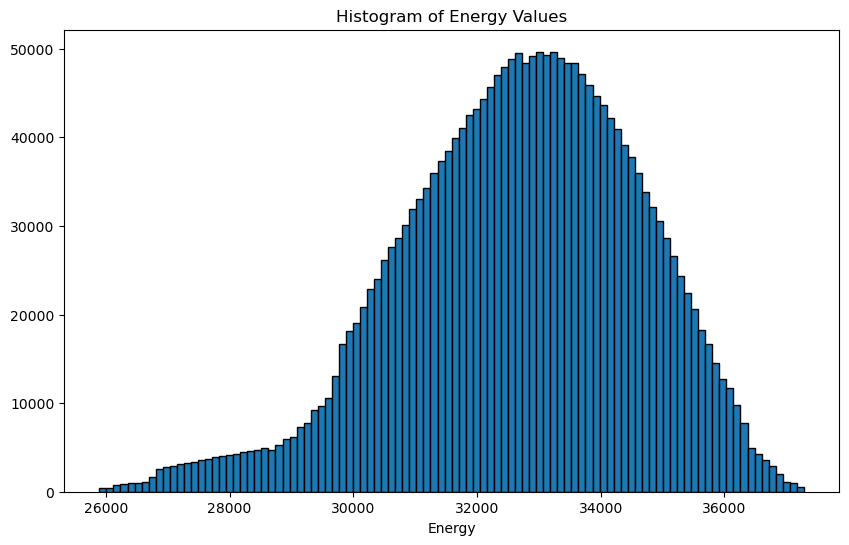

In [5]:
singles_energy = measurement_df.select("energy").to_numpy().flatten()
# plot the histogram of the energy values
energy_counts, energy_edges = np.histogram(singles_energy, bins=100)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(energy_edges[:-1], energy_counts, width=np.diff(energy_edges), edgecolor="black", align="edge")
ax.set_title("Histogram of Energy Values")
ax.set_xlabel("Energy")

In [6]:
# Print min and max of the x, y
x_min, x_max = measurement_df.select("x").to_numpy().min(), measurement_df.select("x").to_numpy().max()
y_min, y_max = measurement_df.select("y").to_numpy().min(), measurement_df.select("y").to_numpy().max()
print(f"x range: {x_min} to {x_max}, y range: {y_min} to {y_max}")

x range: 1 to 25, y range: 1 to 25


In [7]:
# Find the min and max of head_id
head_id_min, head_id_max = measurement_df.select("head_id").to_numpy().min(), measurement_df.select("head_id").to_numpy().max()
print(f"head_id range: {head_id_min} to {head_id_max}")

head_id range: 1 to 20


In [32]:
x_id = measurement_df.select("x").to_numpy().flatten() - 1
y_id = measurement_df.select("y").to_numpy().flatten() - 1
pixel_id = x_id *25 + (24-y_id)
head_id = measurement_df.select("head_id").to_numpy().flatten() + 39
linear_indices = head_id * 625 + pixel_id
# Count the number of events for each pixel and head_id
counts_1d = np.bincount(linear_indices, minlength=80 * 625)
counts_2d = counts_1d.reshape((80, 625))

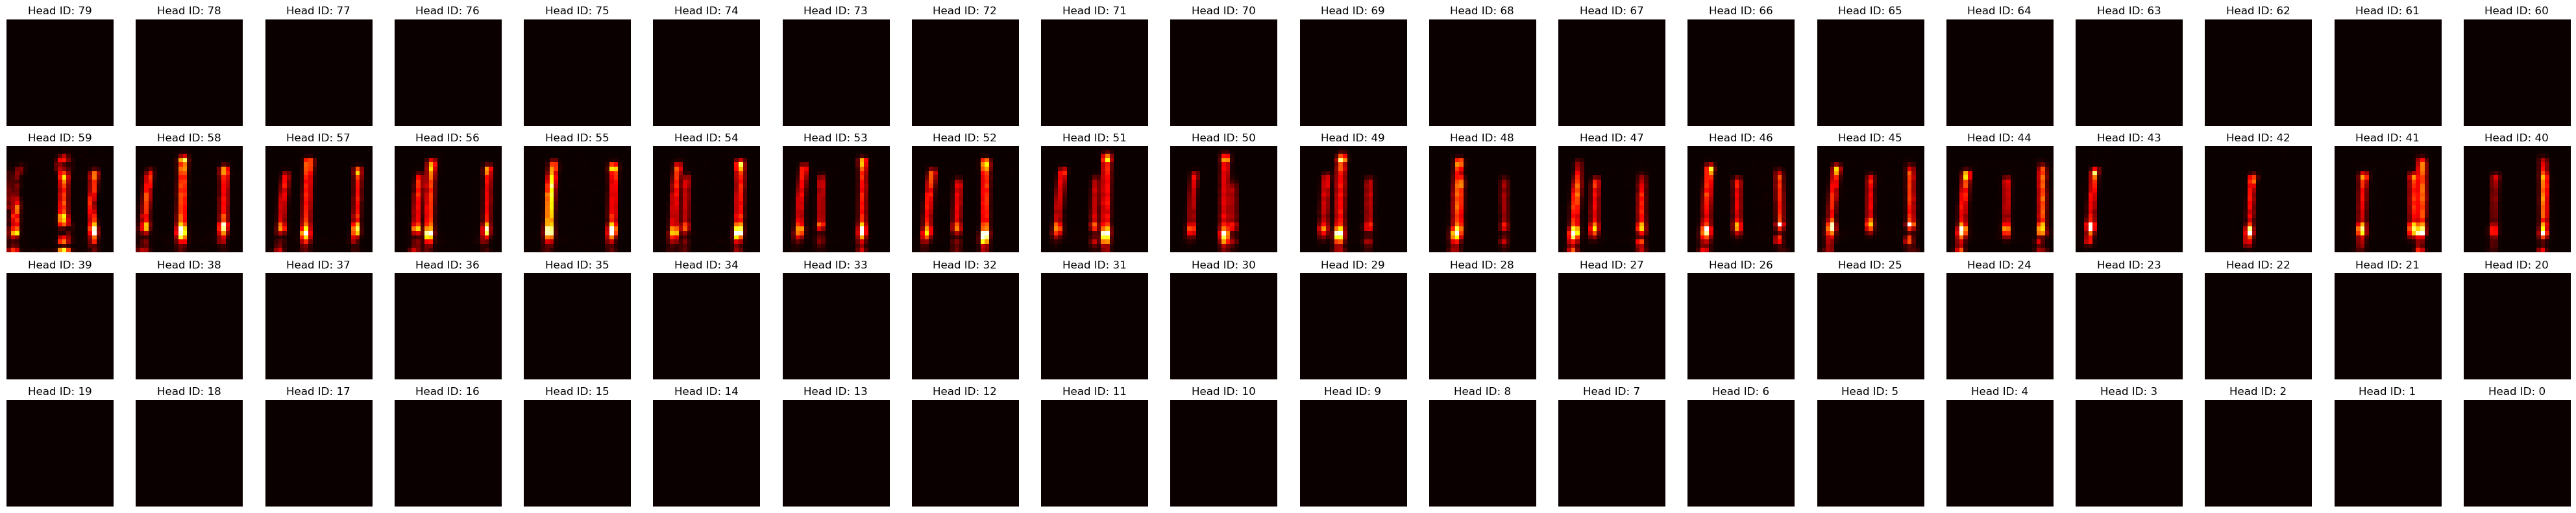

In [33]:
# Plot the counts for each head_id
fig, axes = plt.subplots(4, 20, figsize=(40, 8))
for i in np.arange(80):
    subplot_index = 79-i
    ax = axes[subplot_index // 20, subplot_index % 20]
    ax.imshow(counts_2d[i].reshape((25, 25)), cmap="hot", interpolation="nearest", origin="lower")
    ax.set_title(f"Head ID: {i}")
    ax.axis("off")
plt.tight_layout()


In [34]:
import sparse
ospool_sparse_srm_filename = "job_14965616_stacked_sparse_5d_srm.h5"
ospool_sparse_srm_dir = Path("../")
with h5py.File(ospool_sparse_srm_dir / ospool_sparse_srm_filename, "r") as f:
    ospool_sparse_srm = sparse.COO(
        f['srm/coords'][:], # type: ignore
        f['srm/data'][:], # type: ignore
        shape=tuple(f['srm'].attrs['shape']) # type: ignore
    )

In [26]:
print(f"Loaded sparse SRM with shape: {ospool_sparse_srm.shape} and nnz: {ospool_sparse_srm.nnz}")

Loaded sparse SRM with shape: (80, 625, 80, 80, 80) and nnz: 234883081


In [13]:
from mlem_sparse.io import SparseSRM_IO_Manager, MeasurementMat_IO_Manager
from mlem_sparse.reconstruct import SparseMLEMReconstructor

import torch

# Load the system matrix
srm_io_mgr = SparseSRM_IO_Manager()


In [20]:
ospool_sparse_srm_reshaped = ospool_sparse_srm.reshape((80 * 625, 80 **3))
scipy_coo = ospool_sparse_srm_reshaped.to_scipy_sparse()
scipy_csr = scipy_coo.tocsr()
sparse_mlem_reconstructor_gpu = SparseMLEMReconstructor(
    scipy_csr,
    counts_1d,
    device=torch.device("cuda"),
)

Memory check passed!Transpose requires ~2.63 GB.
Available CUDA memory: 8.65 GB.
Computing explicit transpose matrix...


In [21]:
iters = [1, 3, 5, 10, 20, 30, 40, 50, 70, 100, 200]
estimate_vol_sparse_mlem_tensor_from_gpu = sparse_mlem_reconstructor_gpu.reconstruct(
    iterations=iters
)
estimate_data_np_from_gpu = np.array(
    [
        gpu_tensor.detach().cpu().numpy()
        for gpu_tensor in estimate_vol_sparse_mlem_tensor_from_gpu
    ]
)
del estimate_vol_sparse_mlem_tensor_from_gpu

MLEM Iteration:   0%|          | 0/200 [00:00<?, ?it/s]

In [35]:
scipy_coo = ospool_sparse_srm[40:60].reshape((20 * 625, 80**3)).to_scipy_sparse()
scipy_csr = scipy_coo.tocsr()
sparse_mlem_reconstructor_gpu = SparseMLEMReconstructor(
    scipy_csr,
    counts_2d[40:60].flatten(),
    device=torch.device("cuda"),
)

Memory check passed!Transpose requires ~0.67 GB.
Available CUDA memory: 6.90 GB.
Computing explicit transpose matrix...


In [36]:
iters = [1, 3, 5, 10, 20, 30, 40, 50, 70, 100, 200]
estimate_vol_sparse_mlem_tensor_from_gpu = sparse_mlem_reconstructor_gpu.reconstruct(
    iterations=iters
)
estimate_data_np_from_gpu = np.array(
    [
        gpu_tensor.detach().cpu().numpy()
        for gpu_tensor in estimate_vol_sparse_mlem_tensor_from_gpu
    ]
)
del estimate_vol_sparse_mlem_tensor_from_gpu

MLEM Iteration:   0%|          | 0/200 [00:00<?, ?it/s]

In [37]:

slices = (59, 61)
output_dir = Path("reconstructed_images_3plnsrc_measurement_ospool_srm")/f"z_slices_({slices[0]}-{slices[1]})"

output_dir.mkdir(exist_ok=True, parents=True)


img_shape = (80, 80, 80)
fov_dim_mm = (160.0, 160.0, 160.0)
xy_extent = (
    -fov_dim_mm[0] * 0.5,
    fov_dim_mm[0] * 0.5,
    -fov_dim_mm[1] * 0.5,
    fov_dim_mm[1] * 0.5,
)

for iter_id in range(len(iters)):
    estimate_iter = estimate_data_np_from_gpu[iter_id]
    estimate_iter = estimate_iter.reshape(img_shape)
    img = estimate_iter[:, :, slices[0]:slices[1]].sum(axis=2)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6),layout="constrained")
    im = ax.imshow(img.T, cmap="hot", origin="lower", extent=xy_extent, aspect="equal",interpolation="none")
    ax.set_title(
        f"Reconstructed Image, 3-Line Source Measurements, Iteration {iters[iter_id]}, z-slice {slices[0]}-{slices[1]}"
    )
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    plt.colorbar(im, ax=ax)
    fig.savefig(output_dir / f"reconstructed_image_3plnsrc_iter_{iters[iter_id]}.png", dpi=300)
    plt.close(fig)